# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.
Removendo duplicatas, restam **1'812** entradas.


In [61]:
%%html
<link rel="stylesheet" href="./style.css">

In [62]:
import import_ipynb  # noqa: F401
from treatment import (  # type: ignore
    f3_categorical_columns,
    f3_df,
    f3_numerical_columns,
)


In [63]:
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from kmodes.kprototypes import KPrototypes

from columns import target_columns
from data import a_df, names_of_columns

In [64]:
def plot_boxplots_with_clusters_for_numerical_columns(
    data_frame: pd.DataFrame, numerical_columns: list[str]
):
    n = len(numerical_columns)

    fig, axes = plt.subplots(
        nrows=(n + 1) // 2, ncols=2, figsize=(14, 5 * ((n + 1) // 2))
    )

    axes = axes.flatten()

    for ax, col in zip(axes, numerical_columns):
        sns.boxplot(data=data_frame, x="cluster", y=col, ax=ax)

        ax.set_title(f"{col} por cluster")
        ax.set_xlabel("Cluster")
        ax.set_ylabel(names_of_columns[col])

    # remove eixos vazios
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()
    plt.show()

In [65]:
def plot_boxplot_pair_with_clusters(data_frame: pd.DataFrame, x_axis: str, y_axis: str):
    fig, ax = plt.subplots(figsize=(14, 6))

    sns.boxplot(
        data=data_frame,
        x=x_axis,
        y=y_axis,
        hue="cluster",
        ax=ax,
        palette="tab10",
    )
    ax.set_title(
        f"{names_of_columns[y_axis]} by {names_of_columns[x_axis]} and cluster"
    )
    ax.set_xlabel(names_of_columns[x_axis])
    ax.set_ylabel(names_of_columns[y_axis])

    plt.tight_layout()
    plt.show()


In [66]:
def plot_scatterplot_with_clusters(data_frame: pd.DataFrame, x_axis: str, y_axis: str):
    sns.scatterplot(
        data=data_frame,
        x=x_axis,
        y=y_axis,
        hue="cluster",
        palette="tab10",
    )
    plt.title(f"Clusters: {names_of_columns[x_axis]} × {names_of_columns[y_axis]}")
    plt.show()


In [67]:
def plot_scatterplot_pair_with_clusters(
    data_frame: pd.DataFrame, x_axis: str, y_axis: str
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # XY plot
    sns.scatterplot(
        data=data_frame,
        x=x_axis,
        y=y_axis,
        hue="cluster",
        palette="tab10",
        ax=axes[0],
    )
    axes[0].set_title(
        f"Clusters: {names_of_columns[x_axis]} × {names_of_columns[y_axis]}"
    )

    # YX plot
    sns.scatterplot(
        data=data_frame,
        x=y_axis,
        y=x_axis,
        hue="cluster",
        palette="tab10",
        ax=axes[1],
    )
    axes[1].set_title(
        f"Clusters: {names_of_columns[y_axis]} × {names_of_columns[x_axis]}"
    )

    plt.tight_layout()
    plt.show()


In [68]:
def plot_cluster_as_pillar_graph(data_frame: pd.DataFrame, categorical_column: str):
    proportions = (
        pd.crosstab(
            data_frame["cluster"], data_frame[categorical_column], normalize="index"
        )
        * 100
    )

    ax = proportions.plot(kind="bar", stacked=True, figsize=(10, 5))

    plt.title(f"{names_of_columns[categorical_column]} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Proporção (%)")
    plt.legend(
        title=names_of_columns[categorical_column],
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [69]:
def visualize_clustering(data_frame: pd.DataFrame):
    plot_boxplots_with_clusters_for_numerical_columns(
        data_frame=data_frame,
        numerical_columns=[*f3_numerical_columns, *target_columns],
    )

    plot_cluster_as_pillar_graph(data_frame=data_frame, categorical_column="agriblock")
    plot_cluster_as_pillar_graph(data_frame=data_frame, categorical_column="variety")
    plot_cluster_as_pillar_graph(data_frame=data_frame, categorical_column="soil_type")
    plot_cluster_as_pillar_graph(data_frame=data_frame, categorical_column="nursery")

    for x_axis, y_axis in combinations([*f3_numerical_columns, *target_columns], 2):
        plot_scatterplot_pair_with_clusters(
            data_frame=data_frame,
            x_axis=x_axis,
            y_axis=y_axis,
        )

    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="agriblock", y_axis="paddy_yield_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="agriblock", y_axis="trash_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="agriblock", y_axis="hectares"
    )

    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="variety", y_axis="paddy_yield_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="variety", y_axis="trash_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="variety", y_axis="hectares"
    )

    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="soil_type", y_axis="paddy_yield_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="soil_type", y_axis="trash_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="soil_type", y_axis="hectares"
    )

    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="nursery", y_axis="paddy_yield_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="nursery", y_axis="trash_per_hectare"
    )
    plot_boxplot_pair_with_clusters(
        data_frame=data_frame, x_axis="nursery", y_axis="hectares"
    )

## K-Prototypes


In [70]:
features = f3_categorical_columns + f3_numerical_columns


def cluster_by_k_prototypes(n_clusters: int):
    clustered_df_by_kp = f3_df[features].copy()

    # K-Prototypes expects categorical columns as strings
    for col in f3_categorical_columns:
        clustered_df_by_kp[col] = clustered_df_by_kp[col].astype(str)

    # Identify indexes of categorical indexes
    indexes_of_categorical_columns = [
        clustered_df_by_kp.columns.get_loc(col) for col in f3_categorical_columns
    ]

    # Set parameters
    k_prototypes_protocol = KPrototypes(n_clusters=n_clusters, random_state=42)

    # Clustering
    clusters = k_prototypes_protocol.fit_predict(
        clustered_df_by_kp.to_numpy(), categorical=indexes_of_categorical_columns
    )

    # Add column describing the cluster to the database
    clustered_df_by_kp["cluster"] = clusters

    # Add target variables back for cluster analysis
    clustered_df_by_kp["paddy_yield_per_hectare"] = f3_df["paddy_yield_per_hectare"]
    clustered_df_by_kp["trash_per_hectare"] = f3_df["trash_per_hectare"]

    # Revert scaling
    clustered_df_by_kp["hectares"] = a_df["hectares"]
    clustered_df_by_kp["paddy_yield_per_hectare"] = a_df["paddy_yield_per_hectare"]
    clustered_df_by_kp["trash_per_hectare"] = a_df["trash_per_hectare"]

    return clustered_df_by_kp


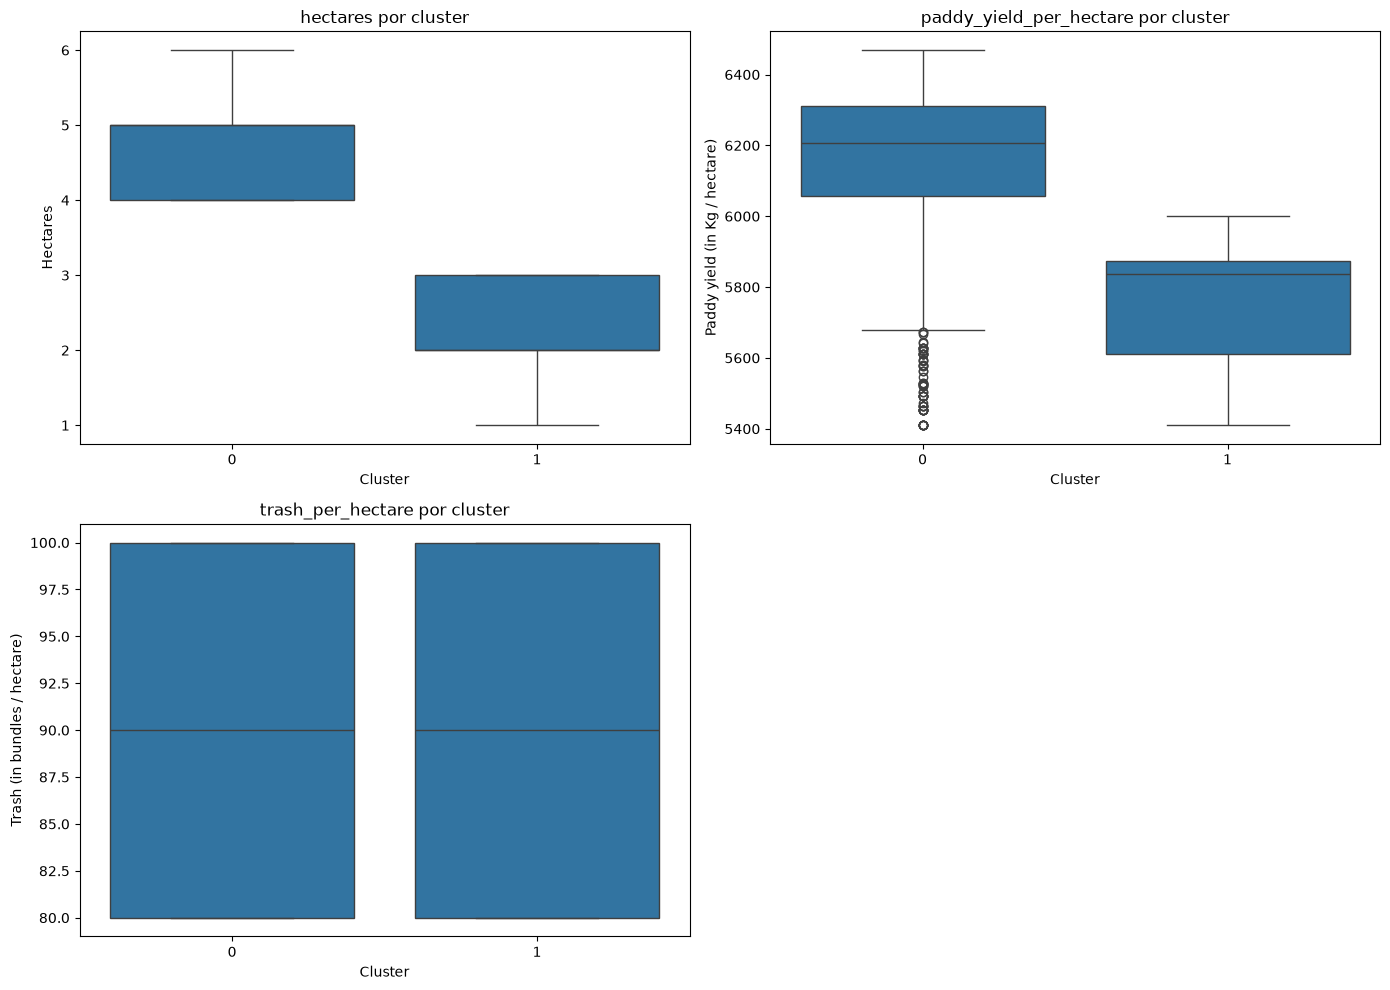

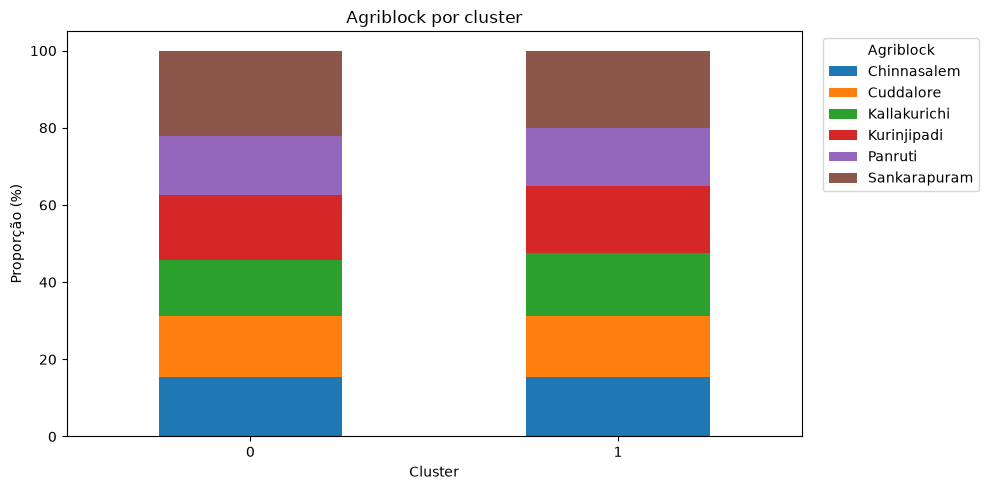

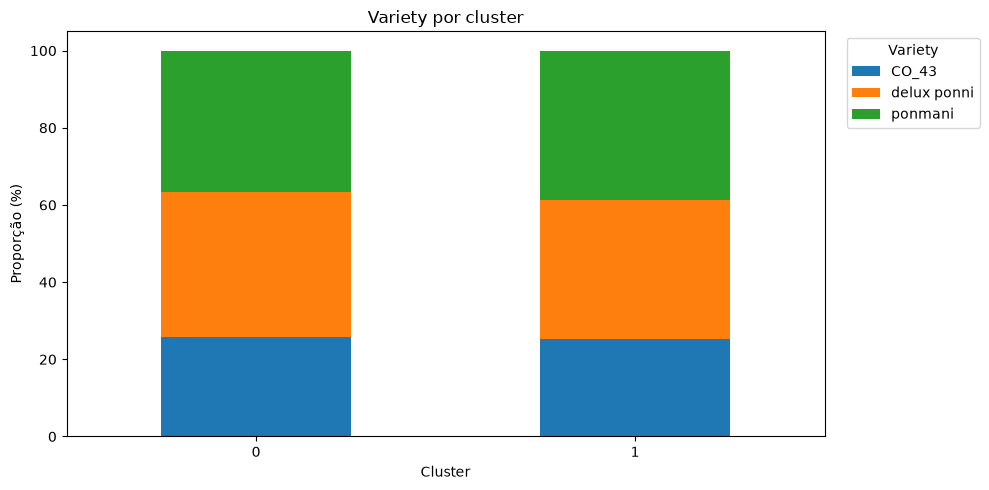

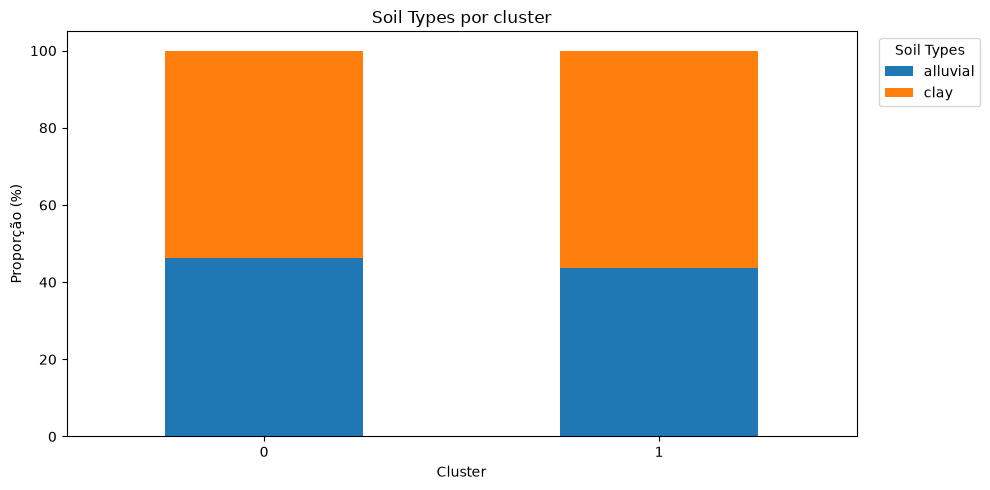

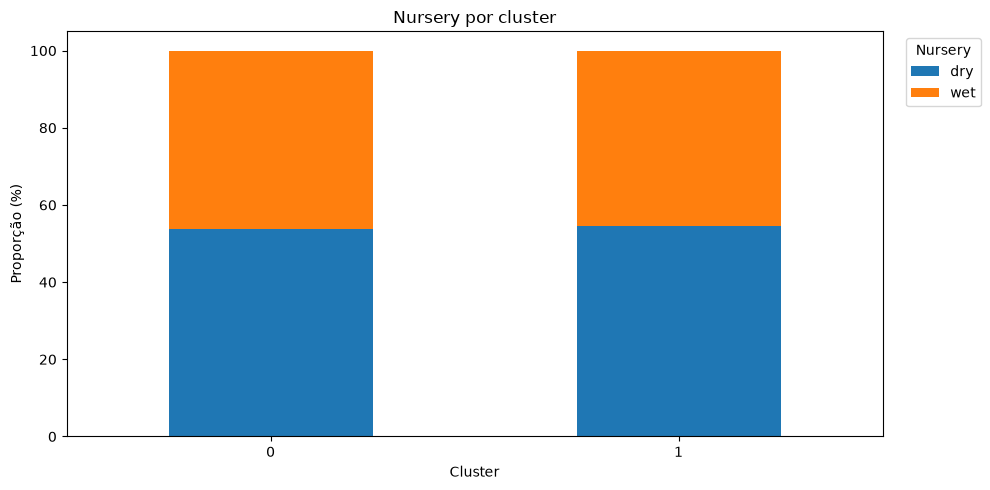

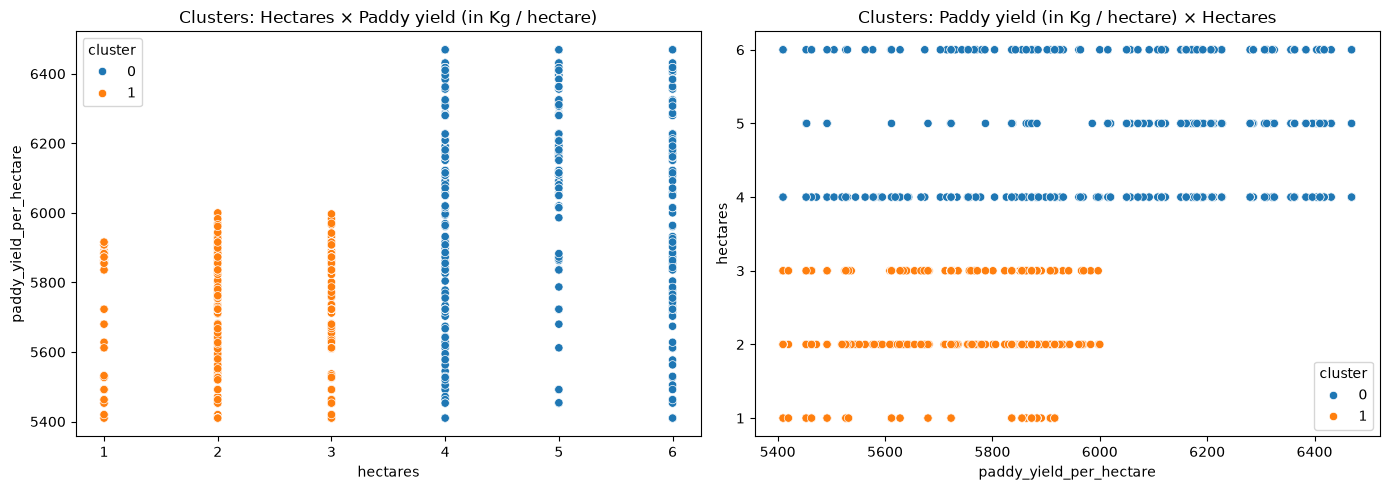

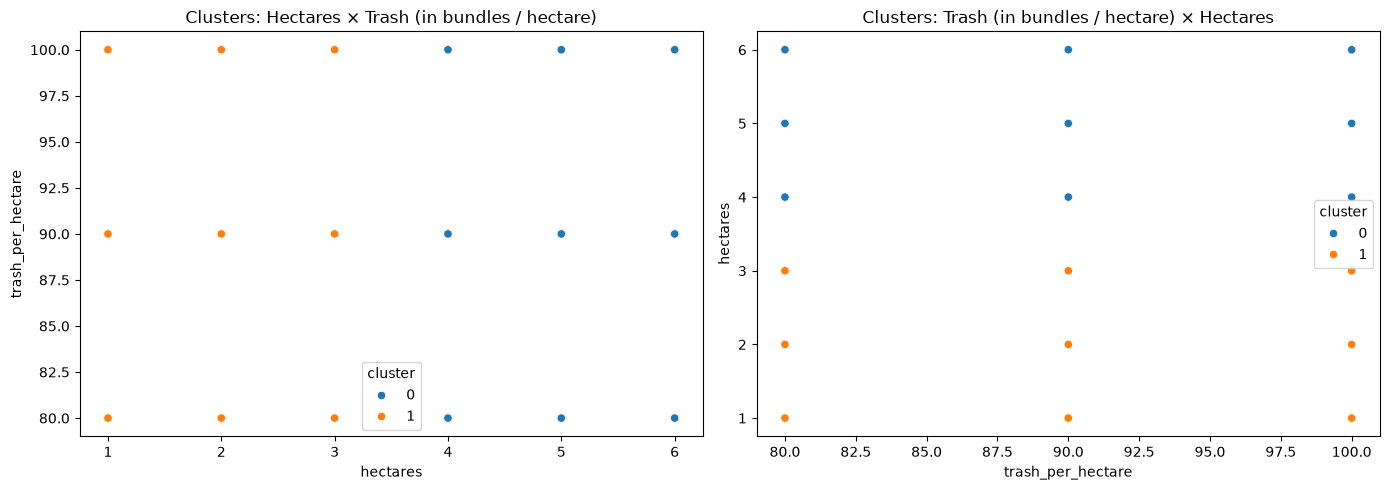

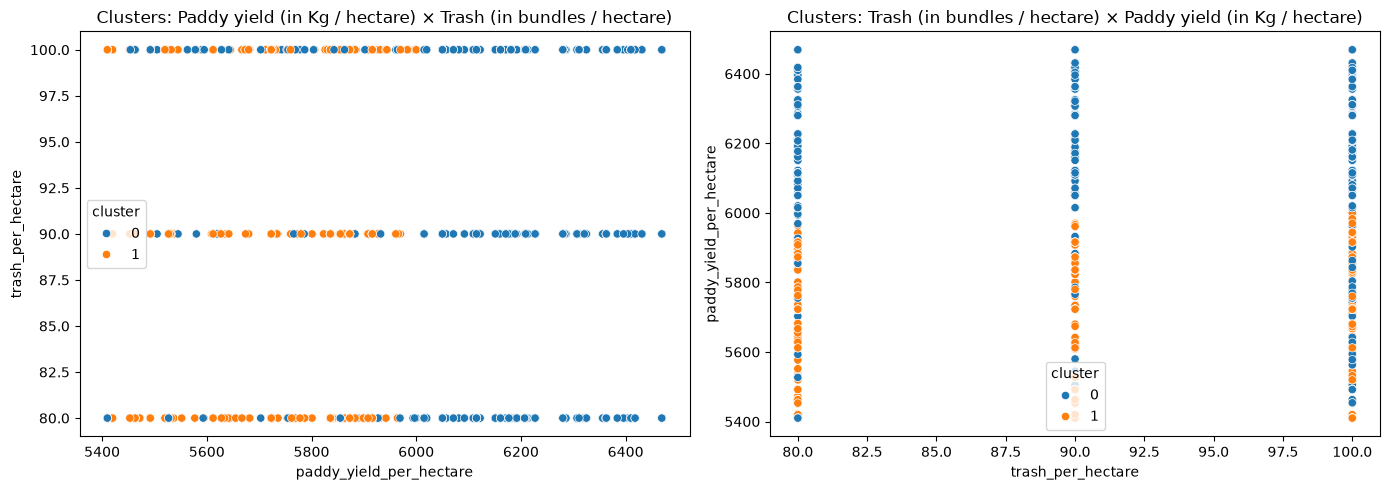

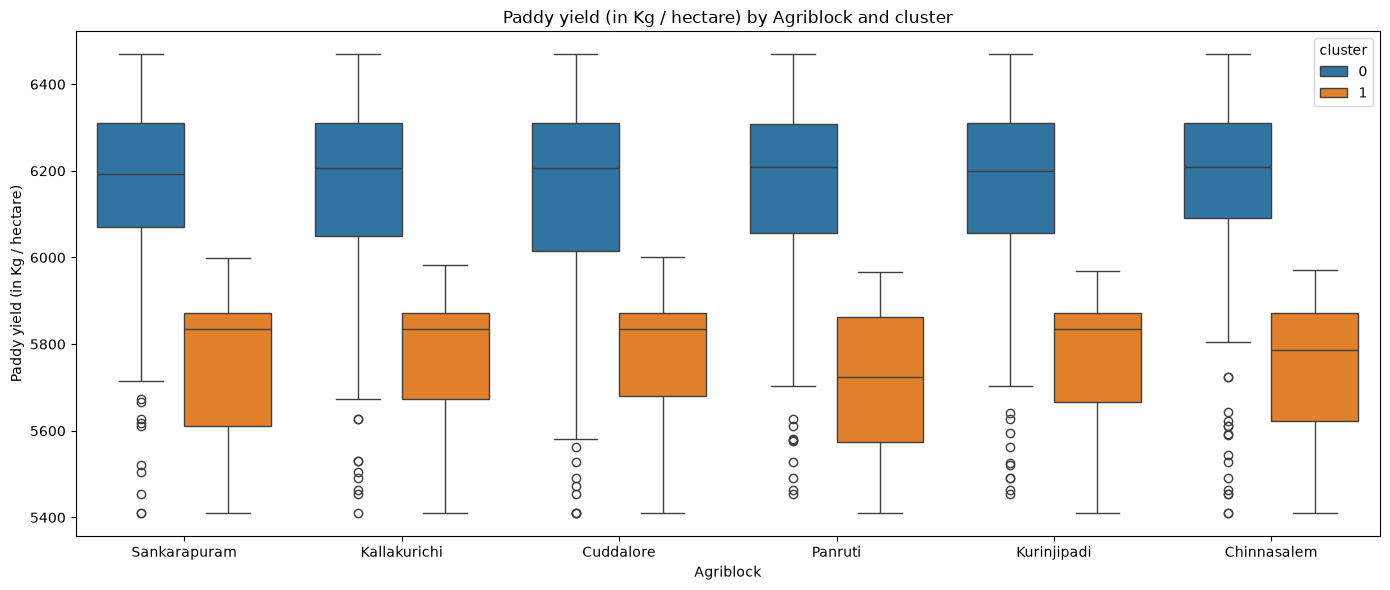

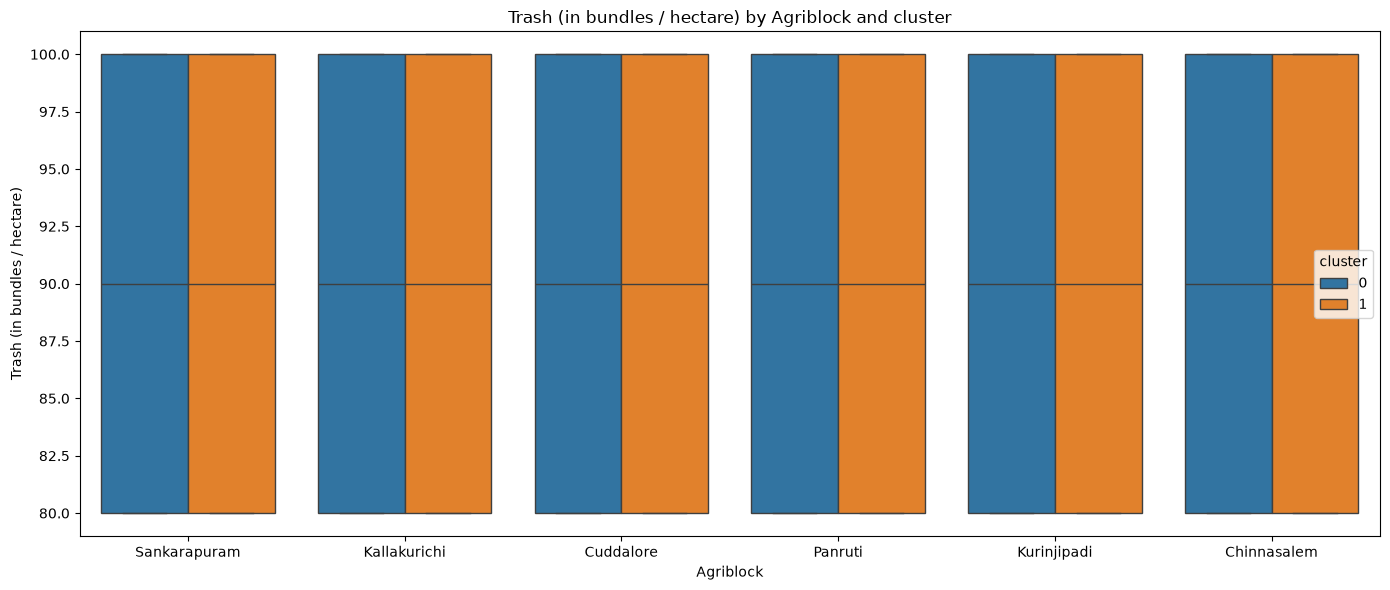

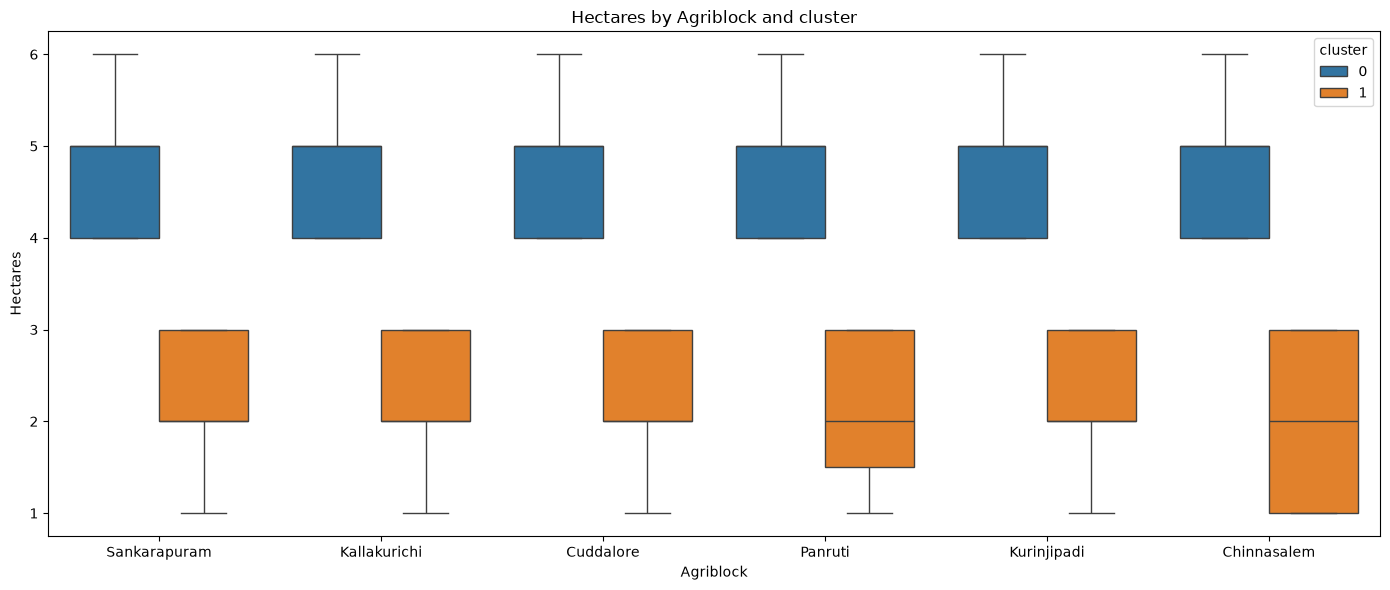

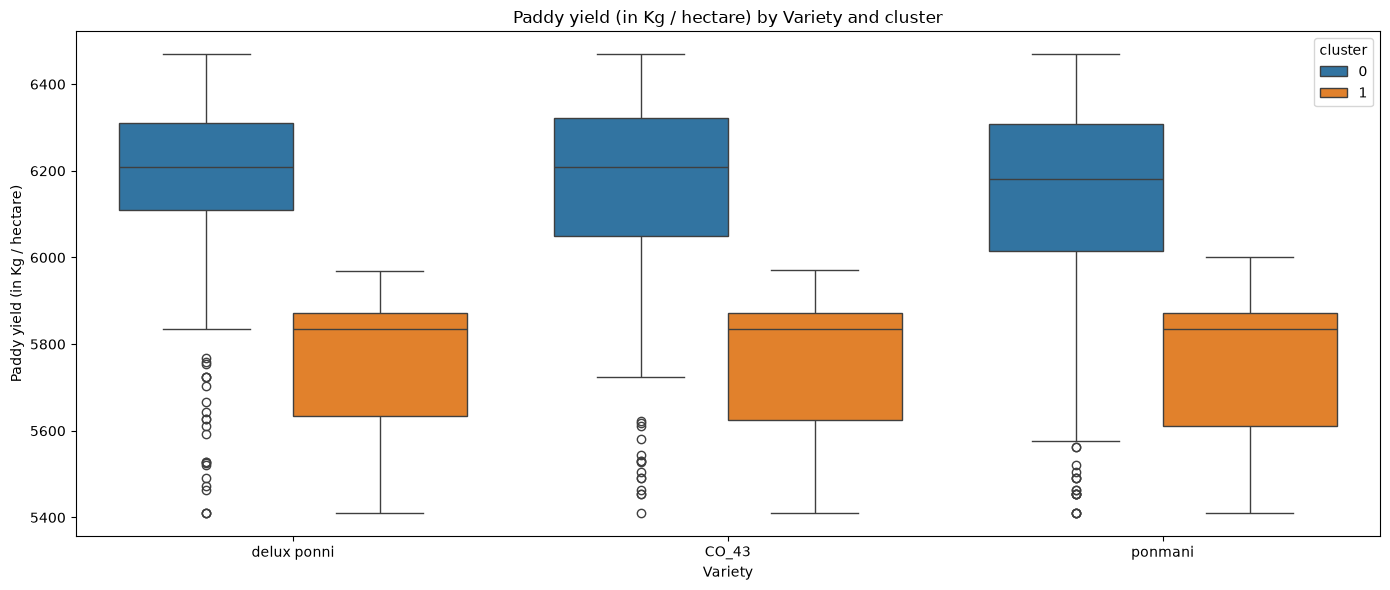

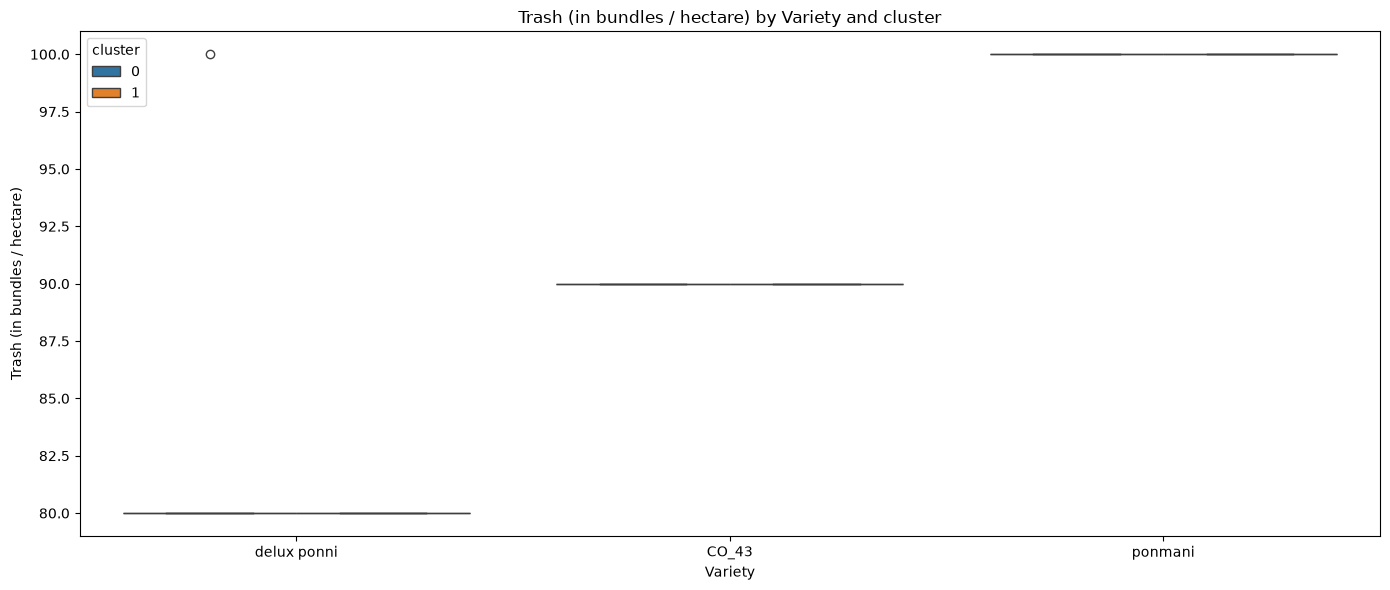

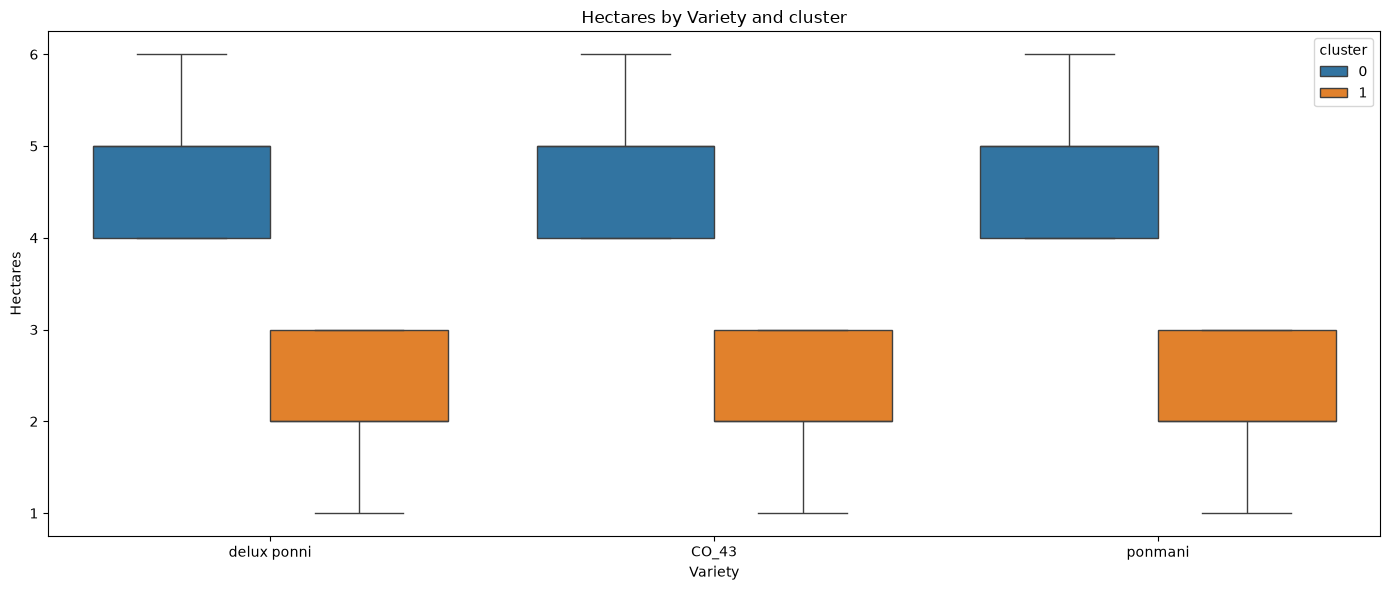

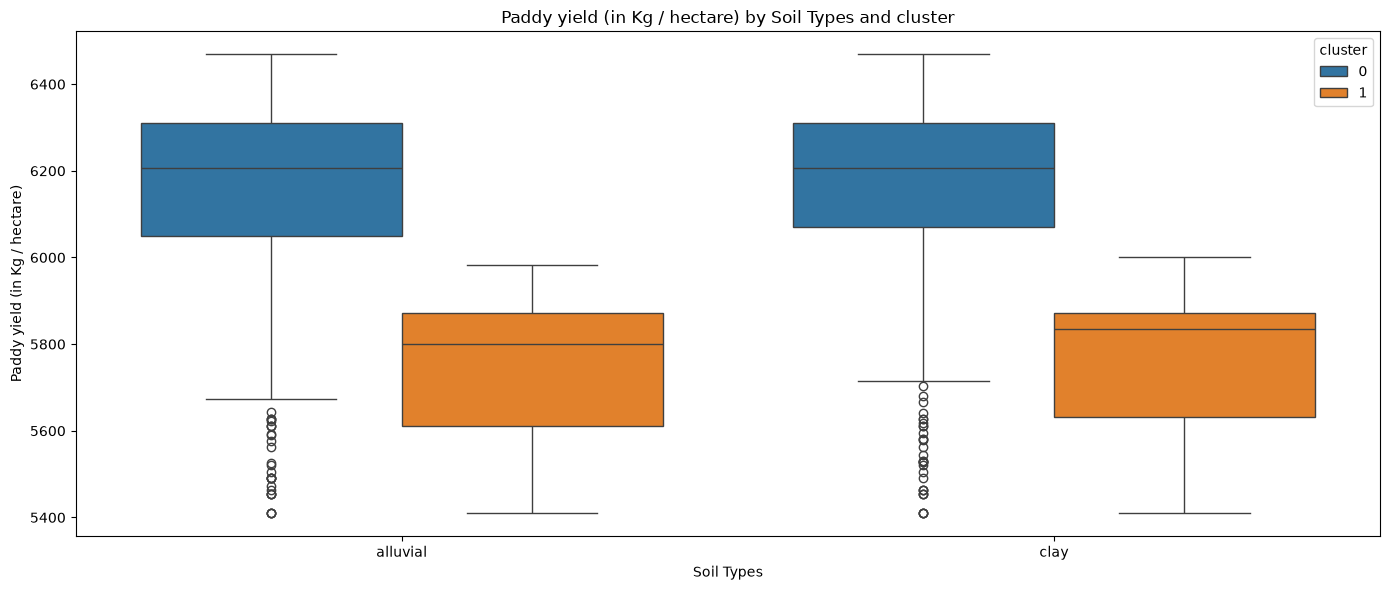

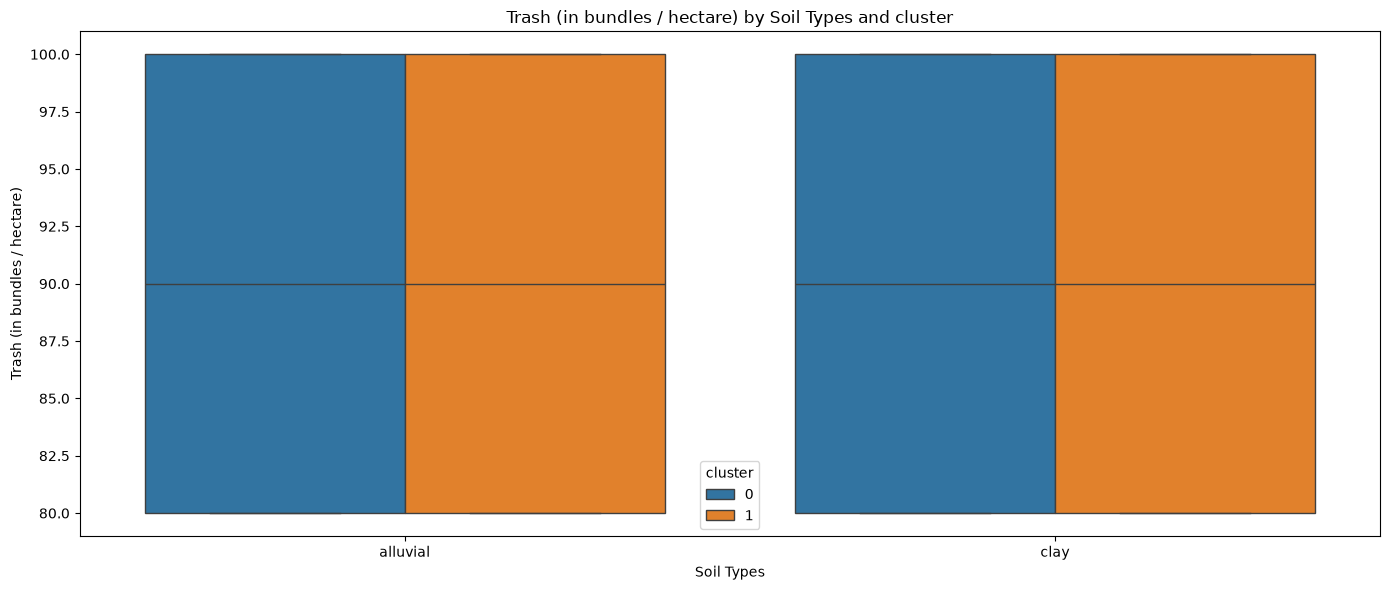

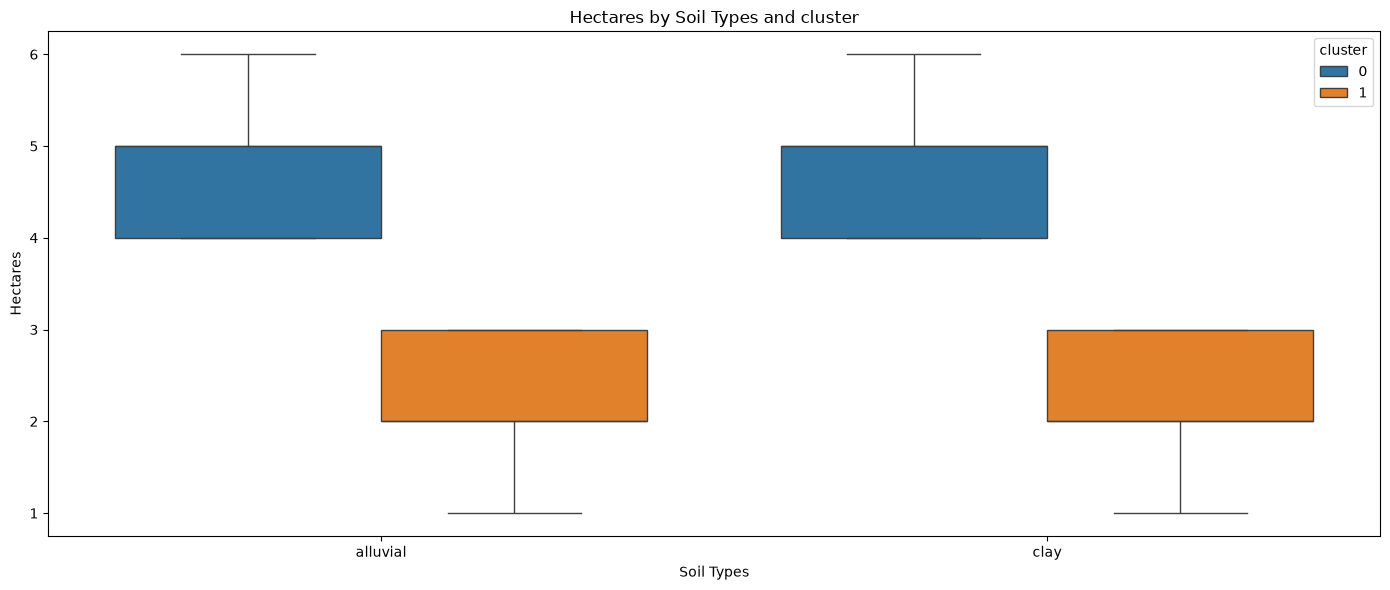

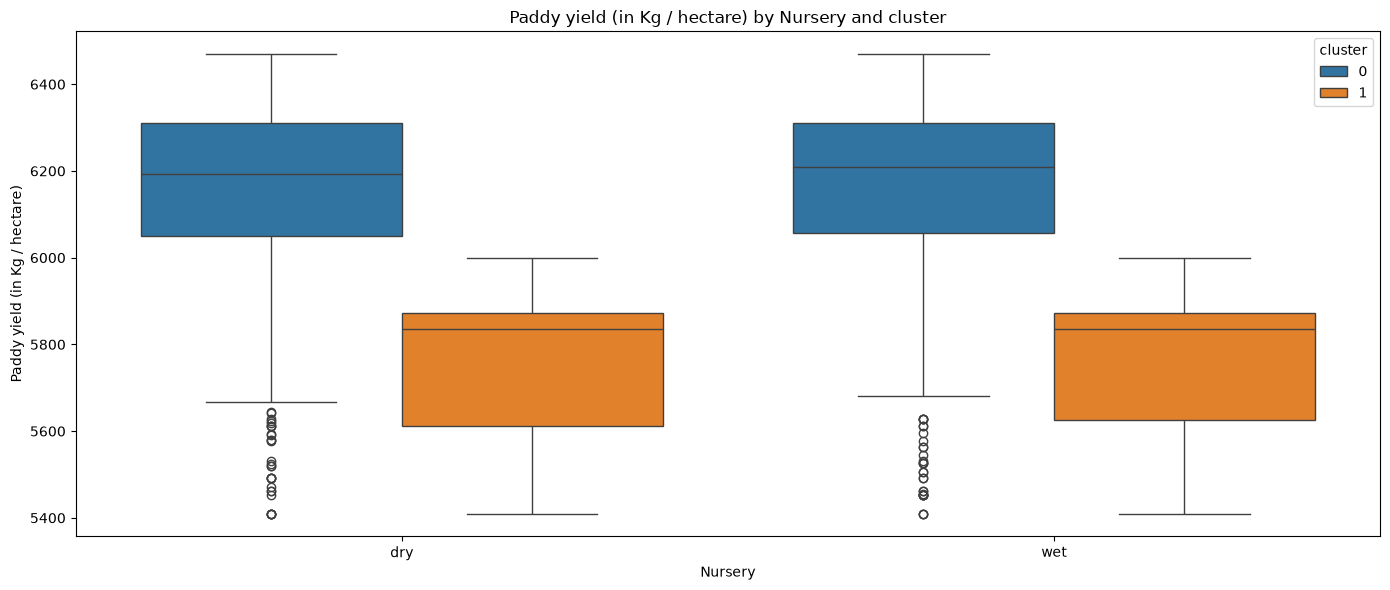

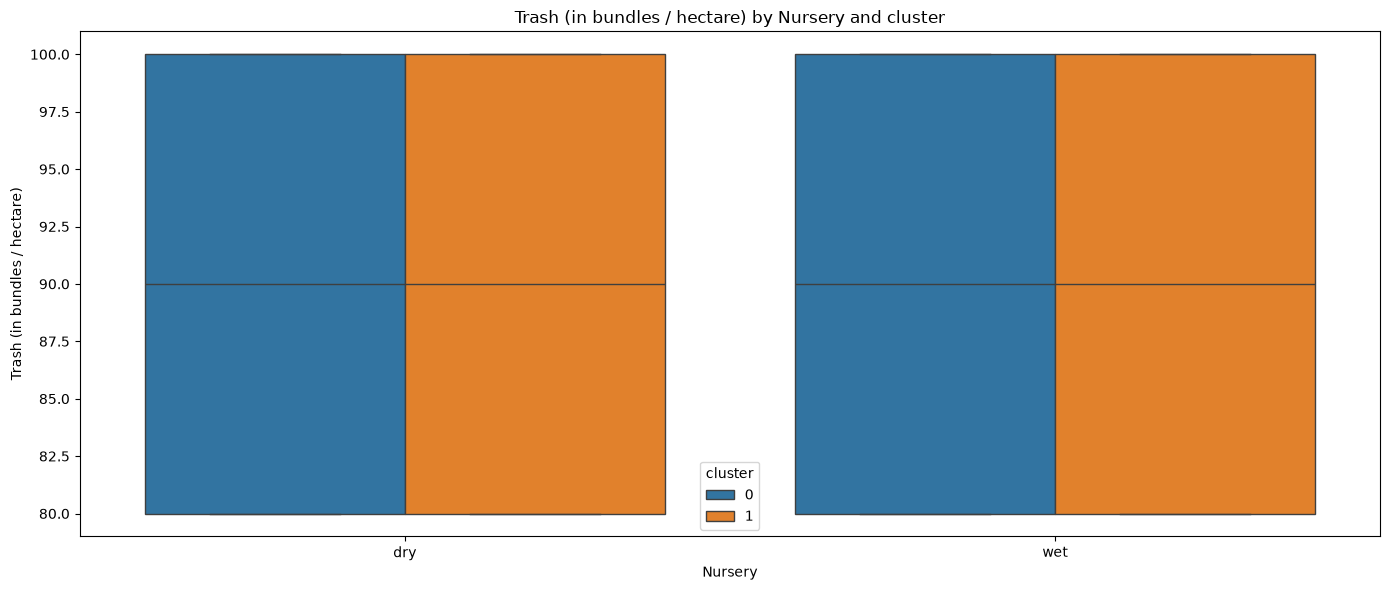

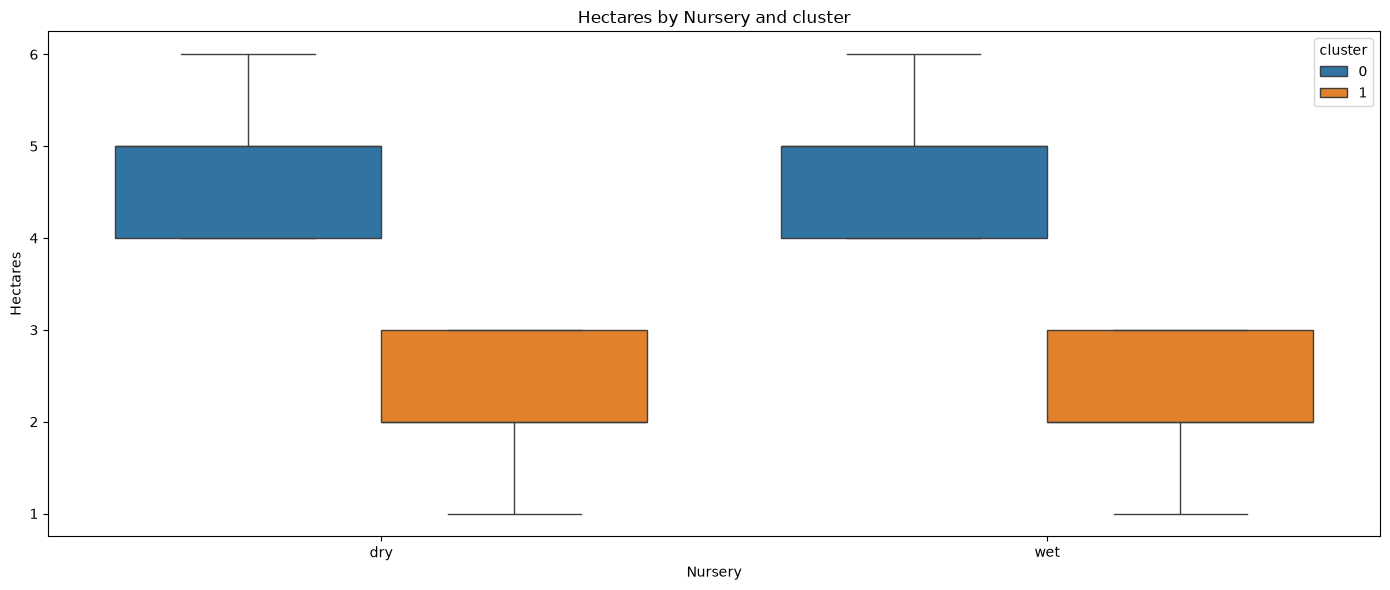

In [71]:
clustering = cluster_by_k_prototypes(n_clusters=2)
visualize_clustering(data_frame=clustering)